---

# Single Neuron Model: The Perceptron

## Perceptron Theory

The Perceptron is a standard single neuron ML model that implements a binary sign activation function for decision-making and prediction.

<p align="center">
    <img src="https://github.com/RandyRDavila/Data_Science_and_Machine_Learning_Spring_2022/blob/main/Lecture_3/ThePerceptronImage.png?raw=1" width="500">
</p>

We will train and test this model on the Spam vs Legitimate Email dataset, compiled for prediction by Muhammad Shahzad on Kaggle:
https://www.kaggle.com/datasets/algozee/spam-vs-legitimate-email-dataset

---

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Ensure local package imports work when notebook kernel isn't editable-installed.
repo_root = Path.cwd().resolve()
if not (repo_root / "src").exists():
    # Fallback for launching from notebook directory.
    repo_root = repo_root.parents[2]
src_path = str(repo_root / "src")
if src_path not in sys.path:
    sys.path.insert(0, src_path)

from rice_ml.Supervised_Learning.perceptron_class import Perceptron

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Import a function for plotting decision boudaries
from mlxtend.plotting import plot_decision_regions

# Set the Seaborn theme
sns.set_theme()

# Reading in the Smartphone Usage Dataset
df = pd.read_csv("spam_email_dataset.csv")

In [2]:
df.iloc[:100]

,email_id,subject,email_text,num_words,num_characters,num_exclamation_marks,num_links,has_suspicious_link,num_attachments,has_attachment,sender_email,sender_domain,sender_reputation_score,email_hour,email_day_of_week,is_weekend,num_recipients,contains_money_terms,contains_urgency_terms,label
0,0,Weekly Report,budget review - Statement our I claim world st...,19,114,0,2,0,2,1,lctvdzm@outlook.com,outlook.com,0.66,19,3,0,23,0,0,0
1,1,Project Update,team sync - President series today already. In...,18,114,0,7,0,0,0,pxyldmi@company.com,company.com,0.95,4,4,0,16,1,0,0
2,2,🔥WIN BIG NOW!!,win free urgent offer limited limited urgent u...,19,126,0,4,1,1,1,atvanls@unknownmail.cc,unknownmail.cc,0.68,3,0,0,10,1,1,1
3,3,🔥WIN BIG NOW!!,guarantee click now cash offer click now guara...,16,101,0,7,1,1,1,qalxcnf@chealdealz.xyz,chealdealz.xyz,0.69,19,5,1,25,1,1,1
4,4,Meeting Reminder,team sync - Significant property hotel not add...,18,111,0,7,1,2,1,xoiccxl@yahoo.com,yahoo.com,0.67,4,5,1,8,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,95,Schedule Confirmation,budget review - Turn sea understand guess. Pic...,15,105,0,4,0,0,0,jkjzdcs@outlook.com,outlook.com,0.82,0,1,0,7,0,0,0
96,96,Limited Offer!!!,offer cash click now offer offer free Nice ind...,15,90,0,4,1,1,1,zamhcmh@freemoney.biz,freemoney.biz,0.32,21,2,0,6,1,1,1
97,97,Weekly Report,budget review - Seat whose professor machine t...,19,133,0,6,1,1,1,rczgcbu@company.com,company.com,0.56,19,3,0,16,0,1,0
98,98,🔥WIN BIG NOW!!,guarantee limited win urgent win click now urg...,14,90,0,0,0,0,0,btqnwew@chealdealz.xyz,chealdealz.xyz,0.40,6,0,0,3,1,1,1


# Dataset Exploration
Fortunately, there are no missing values in the dataset, and there are clear differences in magnitude for several features between mail labeled spam and mail labeled safe. For example, safe emails are more likely to include 2+ attachments and to be sent during general work hours, as portrayed by the plots below. This makes the dataset highly useful for prediction and linear separation.

/var/folders/cc/lczq6cfs5mbbcv25gh6y3_c00000gn/T/ipykernel_47782/1339293158.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='Spam(yes/no)', loc='upper left')


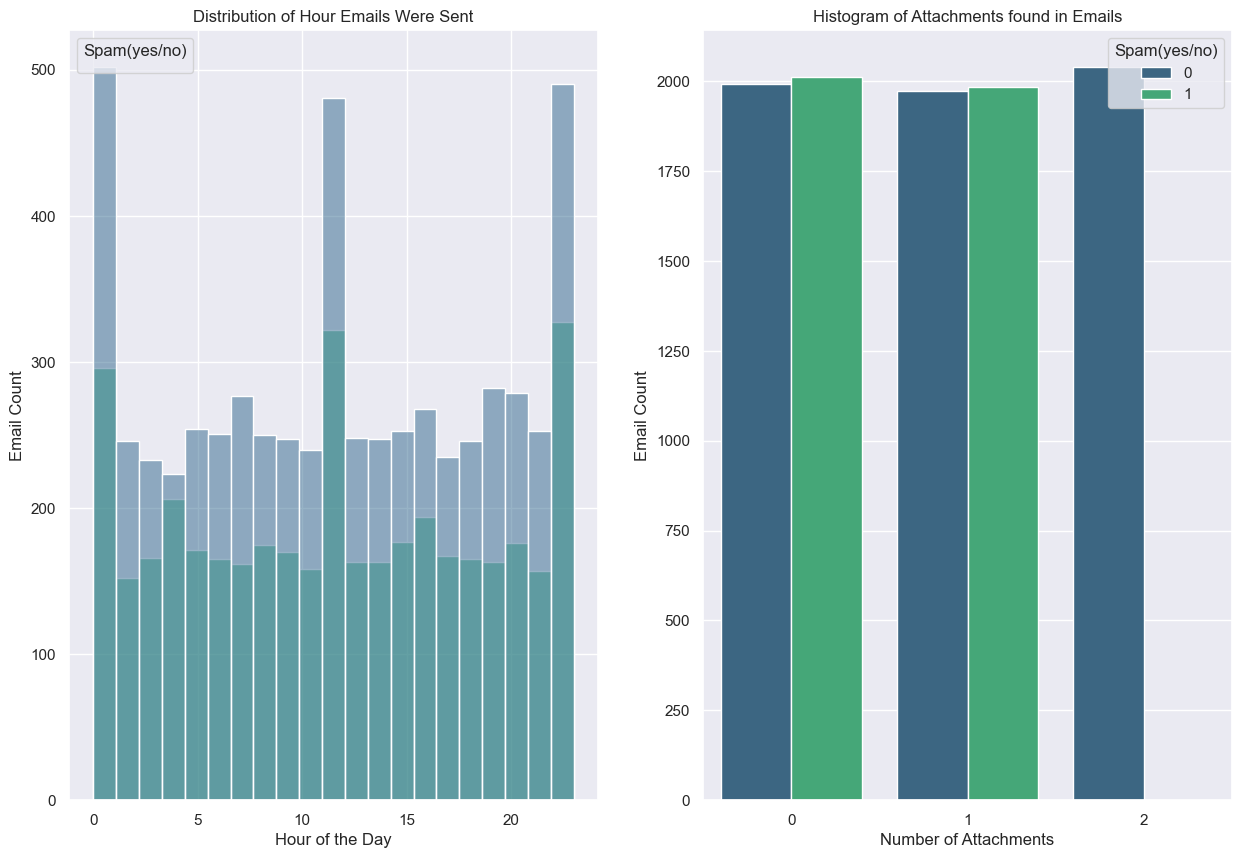


--- 
Missing Values per Column:


ImportError: Missing optional dependency 'tabulate'.  Use pip or conda to install tabulate.

In [4]:
plt.figure(figsize=(15, 10))
plt.subplot(1, 2, 1)
sns.histplot(df, x='email_hour', hue='label', palette='viridis')
plt.title('Distribution of Hour Emails Were Sent')
plt.xlabel('Hour of the Day')
plt.ylabel('Email Count')
plt.legend(title='Spam(yes/no)', loc='upper left')

plt.subplot(1, 2, 2)
sns.countplot(df, x='num_attachments', hue='label', palette='viridis')
plt.title('Histogram of Attachments found in Emails')
plt.xlabel('Number of Attachments')
plt.ylabel('Email Count')
plt.legend(title='Spam(yes/no)', loc='upper right')
plt.show()

print("\n--- ")
print("Missing Values per Column:")
print(df.isnull().sum().to_markdown())
print("\n--- ")

# Preprocessing
No obvious columns need to be dropped based on missing values, but we will drop all identifying and text columns for irrelevance, and select the most helpful predictors. All categorical variables are in numerical format as well.

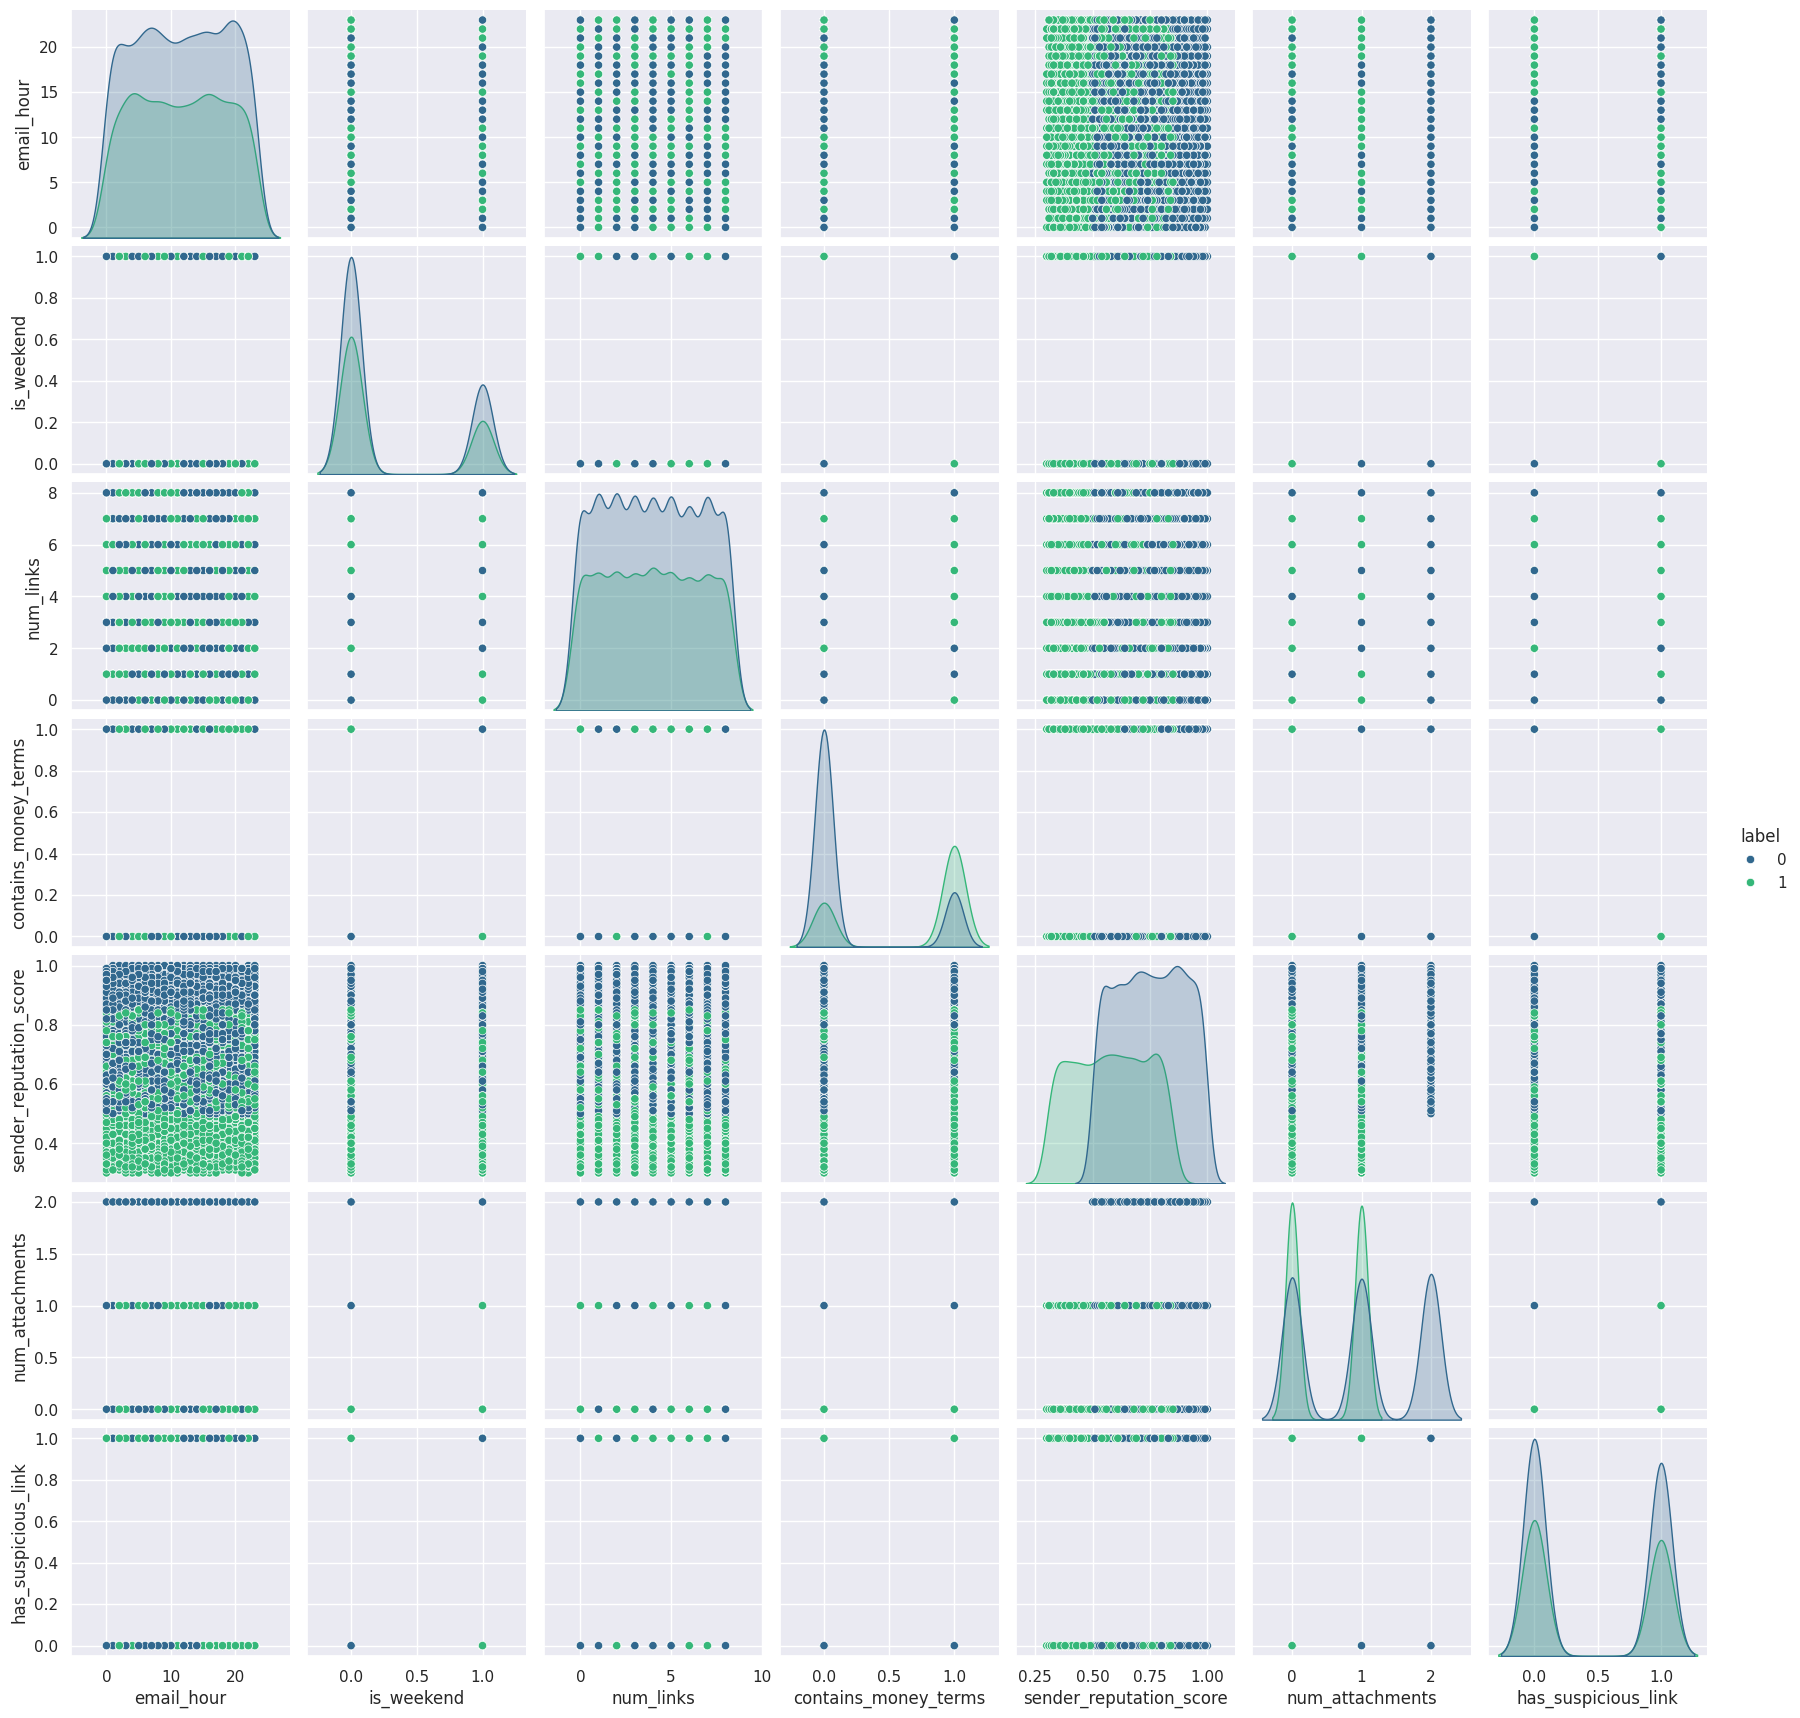

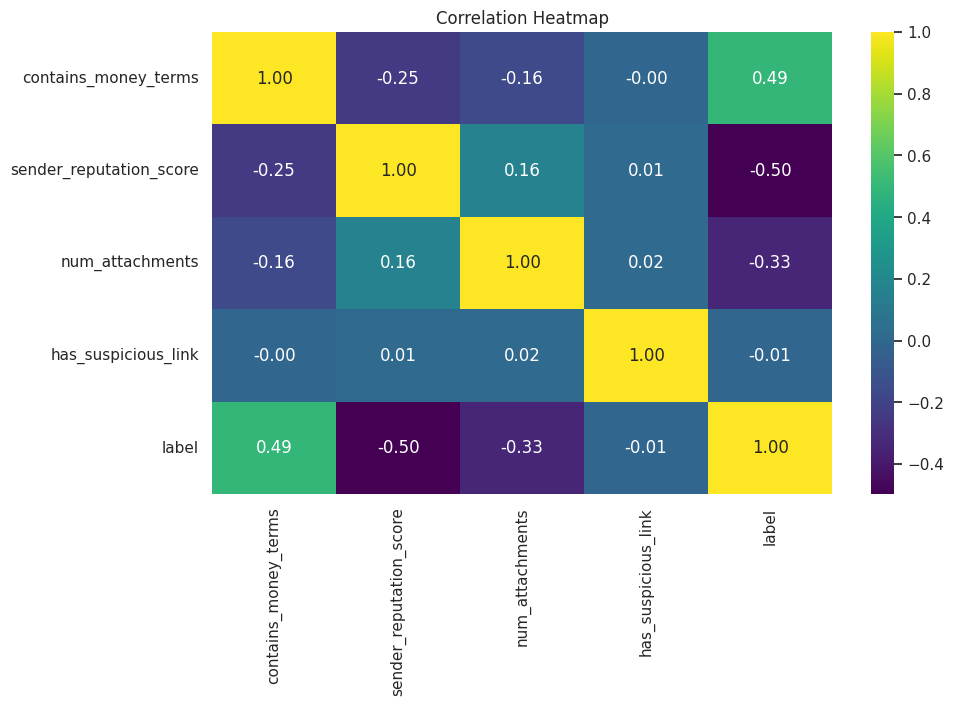

,contains_money_terms,sender_reputation_score,num_attachments,has_suspicious_link,label
0,0,0.66,2,0,0
1,1,0.95,0,0,0
2,1,0.68,1,1,1
3,1,0.69,1,1,1
4,0,0.67,2,1,0


In [ ]:
# Drop all id and text columns for relevance and privacy
df.drop(columns = ['email_id', 'subject', 'email_text', 'sender_email',
                   'sender_domain', 'has_attachment',
                   'num_exclamation_marks'], inplace = True)
selected_feat1 = ['email_hour', 'is_weekend', 'num_links',
                      'contains_money_terms', 'sender_reputation_score',
                      'num_attachments', 'has_suspicious_link', 'label']
# Pair plot
sns.pairplot(df[selected_feat1], hue='label', palette='viridis')
plt.show()
selected_feat2 = ['contains_money_terms', 'sender_reputation_score',
                     'num_attachments', 'has_suspicious_link', 'label']
# Correlation Heatmap of Best Predictors
corr_map = df[selected_feat2].corr()
plt.figure(figsize=(10, 6))
sns.heatmap(corr_map, annot=True, cmap='viridis', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

data = df[selected_feat2]
data.head()


---

The perceptron can take in any number of feature measurements, but for simplicity, we will only focus our attention on the five most correlated features in the dataset. The following code prepares the chosen features.

---

In [ ]:
X = data[['contains_money_terms', 'sender_reputation_score', 'num_attachments', 'has_suspicious_link']].values
y = np.where(data['label'].values == 1, 1, -1)

# Display the first few rows of X and y to confirm
print("First 5 rows of X (features):")
print(X[:5])
print("First 5 values of y (target):")
print(y[:5])

First 5 rows of X (features):
[[0.   0.66 2.   0.  ]
 [1.   0.95 0.   0.  ]
 [1.   0.68 1.   1.  ]
 [1.   0.69 1.   1.  ]
 [0.   0.67 2.   1.  ]]

First 5 values of y (target):
[-1 -1  1  1 -1]


# Building the Perceptron from Scratch
---
We will next write a custom python class that stores a scaling value for the cost function, the number of epochs when training, the weights (and bias), and the errors incured during training on a given instance. Moreover, this python class will also contain a training method, a input method, and a predict method.
---

In [ ]:
class Perceptron(object):
  # A default instance of a Perceptron with a weight update rate(eta) of 0.5
  # and maximum of 20 instances(epochs) of updates
    def __init__(self, eta=0.5, epochs=20):
        self.eta = eta
        self.epochs = epochs
  # Train: iterate through the training set and update weights after each epoch
    def train(self, X, y):
        # Initialize weights with small random numbers plus 1 for bias
        self.w_ = np.random.rand(1 + X.shape[1])
        self.errors_ = [] # For hosting tracking errors

        for _ in range(self.epochs):
            errors = 0
            for xi, label in zip(X, y):
                # Calculate the update amount for weights
                # Update Rule = eta * (Predicted y - Actual y)
                update = self.eta * (label - self.predict(xi))
                # Update weights without bias
                self.w_[:-1] += update * xi
                # Update bias weight
                self.w_[-1] += update
                # Count and store misclassifications
                errors += int(update != 0.0)
            self.errors_.append(errors)
            # When errors = 0, the model has converged
            if errors == 0:
                break
        return self
  # Net Input: compute feature scores using weights and bias
    def net_input(self, X):
        # Net input = dot product of features(X) and weights(w) + bias
        return np.dot(X, self.w_[:-1]) + self.w_[-1]
  # Predict: use the signs of the feature scores to predict new labels
    def predict(self, X):
        # Predict class label based on the sign of the net input
        # Label = 1 if net_input >= 0, else label = -1
        return np.where(self.net_input(X) >= 0.0, 1, -1)

---

Next we can instantiate an instance of the ```Perceptron``` class and also train this instance over 1000 epochs.

---

In [ ]:
# Split data into training and testing sets using sklearn
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
                                                    random_state=42)
# Scale features using Standard Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
# Initialize and train the Perceptron
perceptron = Perceptron(eta=0.01, epochs=1000)
perceptron.train(X_train, y_train)

---

After training has finished we can call the ```Perceptron``` class ```predict``` method to view its current predictions given input features. We can quickly view these predictions on the entries in ```X``` by running the following code in the cell below.

---

In [ ]:
# Predict labels on the features in X
y_hat = perceptron.predict(X_test)

# Compare y_hat and y
print(y_test == y_hat)

[ True False  True ...  True False  True]


---

As we can see from the output of the code above, the predicted values have matched the true values on the given data. We can visualize this in the Euclidian plane by calling the ```plot_decision_regions``` function imported at the top of this notebook. This function will scatter the data in the plane and also show the regions of space where a given point will be classified either -1 or 1. Try running the following code in the cell below.

Testing Accuracy: 0.6755
Confusion Matrix:


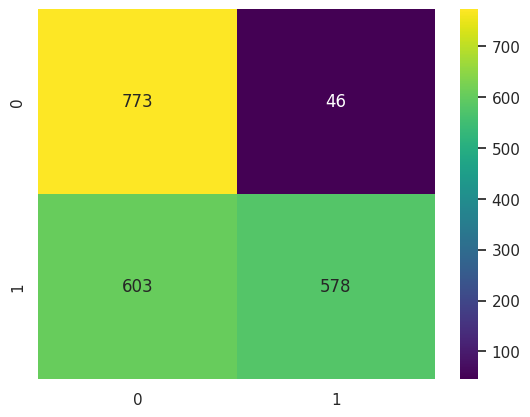

Classification Report:
              precision    recall  f1-score   support

          -1       0.93      0.49      0.64      1181
           1       0.56      0.94      0.70       819

    accuracy                           0.68      2000
   macro avg       0.74      0.72      0.67      2000
weighted avg       0.78      0.68      0.67      2000



In [ ]:
from sklearn.metrics import classification_report
## Classification report and evaluation using sklearn.metrics
# Calculate the Perceptron's Accuracy on the Testing Set
testing_acc = accuracy_score(y_test, y_hat)
print(f'Testing Accuracy: {testing_acc:.4f}')
# Confusion Matrix to display Missclassifications
conf_matrix = confusion_matrix(y_test, y_hat, labels=[1, -1])
print("Confusion Matrix:")
# Confusion heatmap in seaborn
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='viridis')
plt.show()
# Classification Report
y_pred = perceptron.predict(X)
print("Classification Report:")
print(classification_report(y_test, y_hat))

---

As you can see from the output of the code above, we have found a nice linear seperator which has classified our data. But how long did our perceptron model train for? Luckily, when we defined our ```Perceptron``` class we stored the error incured by the model at each iteration of an epoch in the ```errors_``` attribute. We can view these errors over each epoch by running the following code in the cell below.
```python
plt.figure(figsize = (10, 8))
plt.plot(range(1, len(percep.errors_)+1), percep.errors_,
         marker = "o",
         label = "error plot",)
plt.xlabel("Iterations")
plt.ylabel("Missclassifications")
plt.legend()
plt.show()
```

---

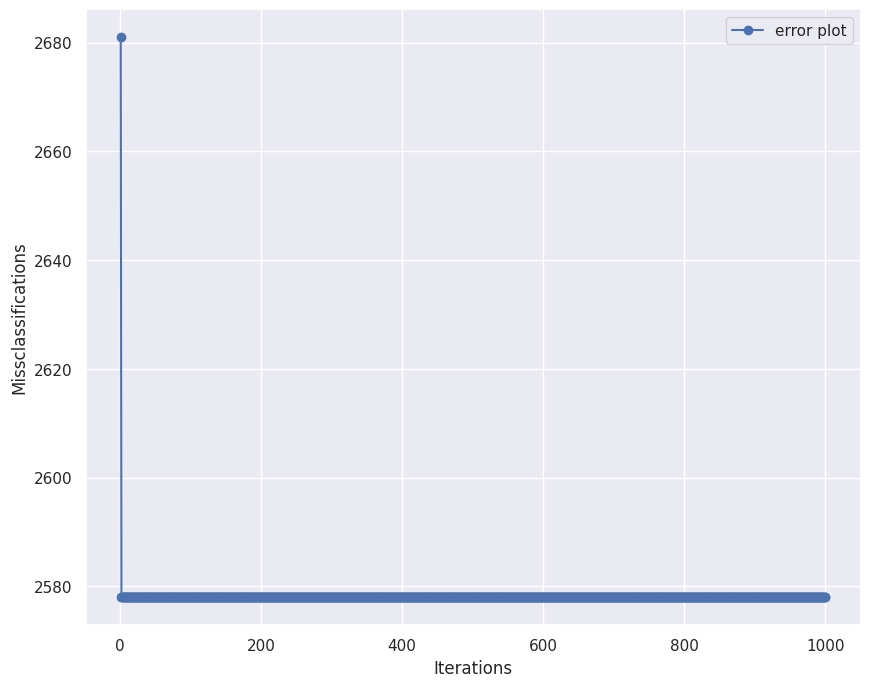

In [ ]:
plt.figure(figsize = (10, 8))
plt.plot(range(1, len(clf.errors_)+1), clf.errors_,
         marker = "o",
         label = "error plot",)
plt.xlabel("Iterations")
plt.ylabel("Missclassifications")
plt.legend()
plt.show()

---

# Conclusion

We have shown that the perceptron model works well on classifying these two species of iris flower. However, the data generated by these measurements and species was *linearly seperable*. What happens if the data is not linearly seperable? I encourage you to repeat each step of this notebook with the "versicolor" and "virginica" flowers and experiment with different possible measurements. Also, I have included the palmer penguins dataset in the Datasets folder. You should also try and implement the perceptron model on that data as well.


---